### **HW #3**

컴퓨터과학과 202315163 김소희

In [1]:
import random
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SEED = 42
EMBEDDING_DIM = 50
EPOCHS = 200
BATCH_SIZE = 64
LEARNING_RATE = 0.01
device = torch.device("cpu")
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |",
             "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__, "| Device:", device, "| Seed:", SEED)

Python: 3.14.6
PyTorch: 2.14.0+cpu | Device: cpu | Seed: 42


---

**공통 준비: 말뭉치와 Skip-gram**

중심 단어 하나로 주변 문맥 단어 하나를 예측한다. 문장의 경계를 넘지 않고 좌우 `window`개 단어를 사용한다.
`Embedding → Linear` 구조에 `CrossEntropyLoss`와 Adam을 사용한다.
negative sampling은 사용하지 않는다. 유사도에는 입력 임베딩을 사용한다.

In [2]:
sentences = ['king is a royal man',
 'queen is a royal woman',
 'king rules the kingdom',
 'queen rules the kingdom',
 'king lives in the palace',
 'queen lives in the palace',
 'prince is a young man',
 'princess is a young woman',
 'prince lives in the palace',
 'princess lives in the palace',
 'man is a male person',
 'woman is a female person',
 'boy is a young male',
 'girl is a young female',
 'dog is an animal',
 'cat is an animal',
 'dog is a pet',
 'cat is a pet',
 'puppy is a young dog',
 'kitten is a young cat',
 'apple is a fruit',
 'banana is a fruit',
 'orange is a fruit',
 'apple is sweet',
 'banana is sweet',
 'orange is sweet',
 'car is a vehicle',
 'bus is a vehicle',
 'truck is a vehicle',
 'car moves on road',
 'bus moves on road',
 'truck moves on road']
corpus = [sentence.lower().split() for sentence in sentences]
vocab = sorted({word for sentence in corpus for word in sentence})
word_to_id = {word: idx for idx, word in enumerate(vocab)}
print("Sentences:", len(corpus), "| Tokens:", sum(map(len, corpus)), "| Vocabulary:", len(vocab))
print("First sentence:", corpus[0])

Sentences: 32 | Tokens: 139 | Vocabulary: 40
First sentence: ['king', 'is', 'a', 'royal', 'man']


In [3]:
def create_skipgram_pairs(tokenized_sentences, mapping, window):
    if window < 1:
        raise ValueError("window must be at least 1")
    pairs = []
    for sentence in tokenized_sentences:
        for i, center in enumerate(sentence):
            for j in range(max(0, i - window), min(len(sentence), i + window + 1)):
                if i != j:
                    pairs.append((mapping[center], mapping[sentence[j]]))
    return pairs

class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, centers):
        return self.output(self.embedding(centers))

def train_skipgram(tokenized_sentences, vocabulary, window, seed=SEED):
    set_seed(seed)
    mapping = {word: idx for idx, word in enumerate(vocabulary)}
    pairs = create_skipgram_pairs(tokenized_sentences, mapping, window)
    pair_tensor = torch.tensor(pairs, dtype=torch.long)
    dataset = TensorDataset(pair_tensor[:, 0], pair_tensor[:, 1])
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    model = SkipGramModel(len(vocabulary), EMBEDDING_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    losses = []
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0.0
        for centers, contexts in loader:
            centers, contexts = centers.to(device), contexts.to(device)
            optimizer.zero_grad()
            loss = criterion(model(centers), contexts)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * centers.size(0)
        losses.append(total_loss / len(dataset))
    model.eval()
    embeddings = model.embedding.weight.detach().cpu().clone()
    return {"model": model, "vocab": list(vocabulary), "word_to_id": mapping,
            "embeddings": embeddings, "normalized": F.normalize(embeddings, dim=1),
            "losses": losses, "pairs": len(pairs), "window": window}

def cosine_similarity(result, word1, word2):
    mapping = result["word_to_id"]
    vectors = result["normalized"]
    return torch.dot(vectors[mapping[word1]], vectors[mapping[word2]]).item()

def most_similar(result, word, top_k=5):
    mapping = result["word_to_id"]
    scores = result["normalized"] @ result["normalized"][mapping[word]]
    ranked = [(candidate, scores[mapping[candidate]].item())
              for candidate in result["vocab"] if candidate != word]
    return sorted(ranked, key=lambda item: (-item[1], item[0]))[:top_k]

def format_neighbors(neighbors):
    return ", ".join(f"{word} ({score:.4f})" for word, score in neighbors)

# 문장 경계와 윈도우 범위를 작은 예제로 확인한다.
toy_mapping = {"a": 0, "b": 1, "c": 2, "d": 3}
assert create_skipgram_pairs([["a", "b", "c"], ["d"]], toy_mapping, 1) == [
    (0, 1), (1, 0), (1, 2), (2, 1)]
assert len(create_skipgram_pairs([["a", "b", "c"]], toy_mapping, 4)) == 6

---

**1. Window = 1과 Window = 4 비교**

두 모델은 같은 말뭉치, 어휘 순서, seed, 초기 가중치와 학습 설정을 사용한다.
윈도우가 커지면 학습 쌍의 수가 늘어나므로 같은 epoch에서도 optimizer 업데이트 횟수는 달라진다.
따라서 이 실험은 같은 말뭉치를 200회 학습했을 때의 비교이다.

In [4]:
results = {window: train_skipgram(corpus, vocab, window) for window in (1, 4)}
show_table(["Window", "학습 쌍 수", "첫 epoch loss", "마지막 epoch loss"],
           [[w, r["pairs"], f"{r['losses'][0]:.4f}", f"{r['losses'][-1]:.4f}"]
            for w, r in results.items()])

query_words = ["king", "queen", "dog", "apple", "car"]
show_table(["단어", "Window = 1: top-5 (cosine)", "Window = 4: top-5 (cosine)"],
           [[word, format_neighbors(most_similar(results[1], word)),
             format_neighbors(most_similar(results[4], word))] for word in query_words])

| Window | 학습 쌍 수 | 첫 epoch loss | 마지막 epoch loss |
| --- | --- | --- | --- |
| 1 | 214 | 3.5824 | 1.3242 |
| 4 | 478 | 3.6388 | 2.1552 |

| 단어 | Window = 1: top-5 (cosine) | Window = 4: top-5 (cosine) |
| --- | --- | --- |
| king | prince (0.3561), princess (0.2367), car (0.2342), vehicle (0.2099), girl (0.1955) | prince (0.3359), vehicle (0.2359), princess (0.2233), person (0.2141), queen (0.1795) |
| queen | puppy (0.3464), apple (0.2625), in (0.2605), man (0.2327), rules (0.2302) | princess (0.3023), rules (0.2371), kingdom (0.2294), puppy (0.2161), man (0.1974) |
| dog | cat (0.3907), woman (0.3529), banana (0.3361), prince (0.3342), male (0.3212) | cat (0.4070), male (0.3110), prince (0.2721), woman (0.2380), boy (0.2264) |
| apple | kitten (0.4436), banana (0.3580), sweet (0.3357), puppy (0.3230), woman (0.2694) | banana (0.4932), pet (0.3871), kitten (0.3639), orange (0.3229), fruit (0.3221) |
| car | truck (0.2787), girl (0.2559), bus (0.2540), on (0.2492), king (0.2342) | bus (0.3840), truck (0.3421), pet (0.2820), fruit (0.1999), king (0.1776) |

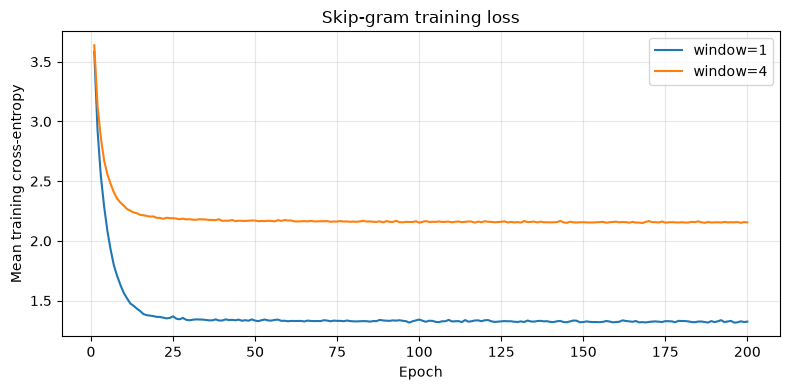

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for window, result in results.items():
    ax.plot(range(1, EPOCHS + 1), result["losses"], label=f"window={window}")
ax.set(xlabel="Epoch", ylabel="Mean training cross-entropy", title="Skip-gram training loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**결과 해석**

Window = 1은 바로 옆 단어만 보고, Window = 4는 이 말뭉치의 각 문장에 있는 다른 단어를 모두 본다.
문장 길이가 최대 5이므로 학습 쌍은 214개에서 478개로 늘어난다.
좁은 윈도우에서는 `is`, `a`처럼 여러 의미 범주가 공유하는 가까운 문맥의 영향이 크다.
넓은 윈도우에서는 `fruit`, `sweet`, `vehicle`, `road`처럼 더 먼 단어도 직접 학습에 포함된다.

실행 결과 `apple`의 top-5는 window=1에서 `kitten, banana, sweet, puppy, woman`,
window=4에서 `banana, pet, kitten, orange, fruit`였다. 후자에서 과일 관련 단어가 더 많이 나타났다.
`car`도 window=4에서 `bus`와 `truck`이 상위 두 단어였고, `queen`의 최근접 단어는 `puppy`에서 `princess`로 바뀌었다.
반면 관련 없는 단어도 여전히 상위에 남았다. 문장 수가 적고 임베딩이 50차원이어서 의미 관계가 완벽하게 정리되지는 않는다.

Window=4의 최종 loss가 더 큰 것은 더 다양한 문맥 단어를 예측하기 때문일 수 있다.
예측 대상 분포가 다른 두 학습 손실만으로 임베딩의 품질을 판정할 수는 없다.

---

**2. 선택한 단어 쌍의 코사인 유사도**

$$\operatorname{cos}(u,v)=\frac{u^T v}{\|u\|_2\|v\|_2}$$

1에 가까울수록 벡터 방향이 비슷하고, 0은 직교, -1은 반대 방향이다.
여기서 음의 유사도가 곧 반의어 관계라는 뜻은 아니다. 두 윈도우에서 여섯 쌍을 모두 비교한다.

In [6]:
selected_pairs = [("king", "queen"), ("dog", "cat"), ("apple", "banana"),
                  ("car", "bus"), ("king", "banana"), ("dog", "car")]
show_table(["단어 쌍", "Window = 1", "Window = 4"],
           [[f"{a} – {b}"] + [f"{cosine_similarity(results[w], a, b):.4f}" for w in (1, 4)]
            for a, b in selected_pairs])
for window, result in results.items():
    scores = [(a, b, cosine_similarity(result, a, b)) for a, b in selected_pairs]
    highest, lowest = max(scores, key=lambda x: x[2]), min(scores, key=lambda x: x[2])
    print(f"Window={window}: 선택한 6쌍 중 최고 {highest[0]}–{highest[1]} ({highest[2]:.4f}), "
          f"최저 {lowest[0]}–{lowest[1]} ({lowest[2]:.4f})")

| 단어 쌍 | Window = 1 | Window = 4 |
| --- | --- | --- |
| king – queen | 0.1394 | 0.1795 |
| dog – cat | 0.3907 | 0.4070 |
| apple – banana | 0.3580 | 0.4932 |
| car – bus | 0.2540 | 0.3840 |
| king – banana | 0.1460 | 0.0026 |
| dog – car | -0.1103 | -0.1155 |

Window=1: 선택한 6쌍 중 최고 dog–cat (0.3907), 최저 dog–car (-0.1103)
Window=4: 선택한 6쌍 중 최고 apple–banana (0.4932), 최저 dog–car (-0.1155)


**결과 해석**

선택한 여섯 쌍 중 window=1의 최대 유사도는 `dog–cat` **0.3907**,
window=4의 최대 유사도는 `apple–banana` **0.4932**였다.
최소는 두 경우 모두 `dog–car`로 각각 **-0.1103**, **-0.1155**였다.
Window=4에서 `king–queen`, `dog–cat`, `apple–banana`, `car–bus`의 유사도가 모두 증가했고,
서로 다른 의미 범주의 `king–banana`는 0.1460에서 0.0026으로 감소했다.
이 실행에서는 넓은 문맥이 해당 의미 관계를 더 잘 반영했지만, 작은 말뭉치와 단일 seed의 관찰이라는 한계가 있다.

---

**3. 2차원 PCA 시각화**

과제에 제시된 12개 단어를 모두 표시한다. 각 모델의 전체 어휘 임베딩에 PCA를 적합한 뒤,
선택 단어의 **실제 어휘 ID**로 좌표를 가져온다. 선택 단어 목록의 순번을 어휘 ID로 사용하지 않는다.
두 모델은 PCA를 별도로 적합하므로 패널 사이의 축 방향이나 절대 좌표를 직접 비교하지 않는다.

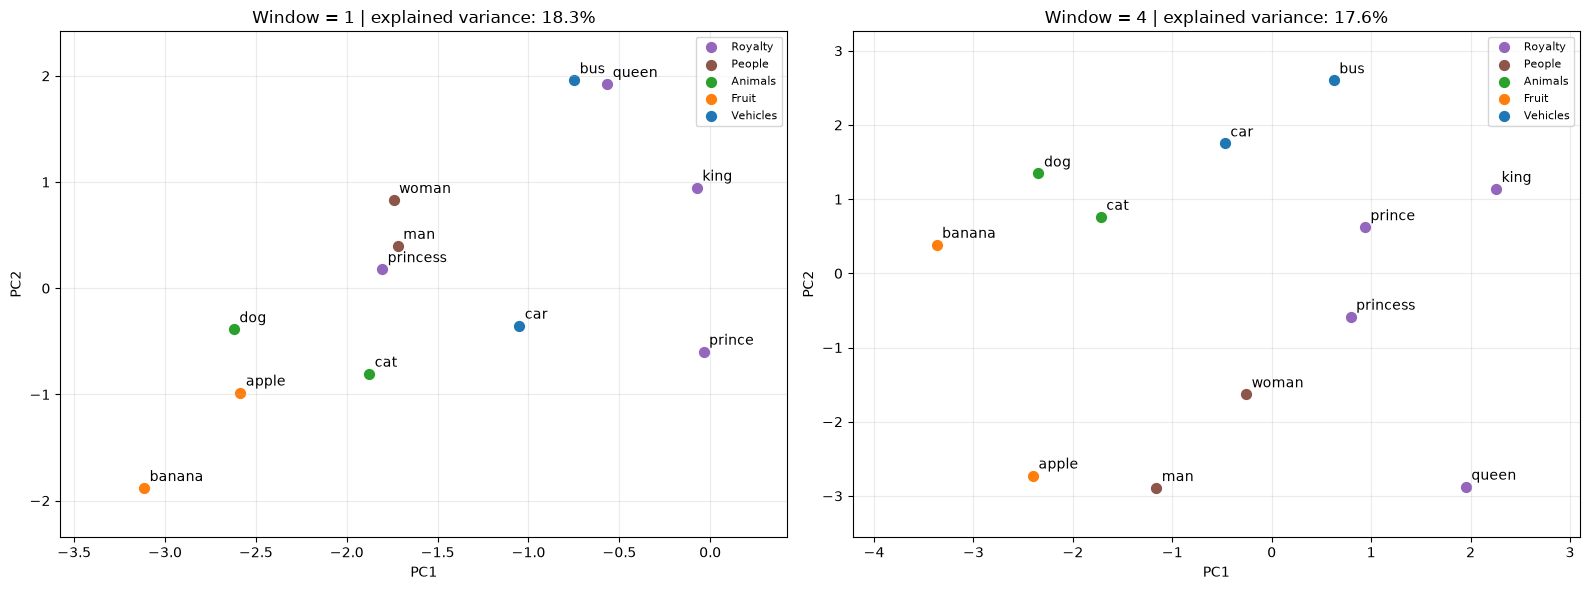

| Window | PC1 설명분산 | PC2 설명분산 | 합계 |
| --- | --- | --- | --- |
| 1 | 9.89% | 8.41% | 18.30% |
| 4 | 10.21% | 7.40% | 17.60% |

In [7]:
plot_groups = {
    "Royalty": ["king", "queen", "prince", "princess"],
    "People": ["man", "woman"],
    "Animals": ["dog", "cat"],
    "Fruit": ["apple", "banana"],
    "Vehicles": ["car", "bus"],
}
plot_words = [word for group in plot_groups.values() for word in group]
colors = dict(zip(plot_groups, ["tab:purple", "tab:brown", "tab:green", "tab:orange", "tab:blue"]))
pca_results = {}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (window, result) in zip(axes, results.items()):
    pca = PCA(n_components=2, svd_solver="full")
    coordinates = pca.fit_transform(result["embeddings"].numpy())
    pca_results[window] = (pca, coordinates)
    for group, words in plot_groups.items():
        ids = [result["word_to_id"][word] for word in words]
        ax.scatter(coordinates[ids, 0], coordinates[ids, 1], label=group, c=colors[group], s=50)
        for word, idx in zip(words, ids):
            ax.annotate(word, coordinates[idx], xytext=(4, 5), textcoords="offset points", fontsize=10)
    retained = pca.explained_variance_ratio_.sum()
    ax.set(title=f"Window = {window} | explained variance: {retained:.1%}", xlabel="PC1", ylabel="PC2")
    ax.grid(alpha=0.25)
    ax.margins(x=0.15, y=0.12)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

show_table(["Window", "PC1 설명분산", "PC2 설명분산", "합계"],
           [[w, f"{p.explained_variance_ratio_[0]:.2%}", f"{p.explained_variance_ratio_[1]:.2%}",
             f"{p.explained_variance_ratio_.sum():.2%}"] for w, (p, _) in pca_results.items()])

**결과 해석**

Window=1에서는 `man–woman`이 가깝고 `dog–cat`, `apple–banana`도 각각 같은 쪽에 위치한다.
반면 `car–bus`, `king–queen`은 가까운 군집을 이루지 않는다.
Window=4에서는 `dog–cat`, `car–bus`, `king–prince`가 비교적 가까이 보이지만,
`apple–banana`와 `king–queen`은 여전히 떨어져 있다. 관련 단어가 항상 모이는 그림은 아니다.

두 주성분이 보존하는 분산은 window=1에서 **18.30%**, window=4에서 **17.60%** 에 불과하다.
특히 window=4의 `apple–banana`는 원래 50차원 코사인 유사도가 0.4932인데도 2차원 그림에서는 멀다.
PCA는 원본 임베딩의 분산을 보존하는 투영이며, 2차원 유클리드 거리와 50차원 코사인 유사도는 같은 척도가 아니다.
따라서 그림은 일부 관계를 살펴보는 보조 자료로 사용하고, 의미 유사도는 2번의 수치와 함께 해석한다.

---

**4. 문장 추가 전후의 apple 비교**

1번에서 학습한 **window=4 모델**을 문장 추가 전 모델로 사용한다.
아래 8개 문장을 기존 말뭉치에 추가한 다음, 토큰화와 어휘 사전 생성을 다시 수행한다.
`train_skipgram` 함수는 새 말뭉치와 어휘 사전으로 학습 쌍을 생성하고 모델을 처음부터 학습한다.
Window=4, 임베딩 50차원, Adam(lr=0.01), 배치 크기 64, 200 epoch는 동일하게 유지한다.
각 모델의 어휘에서 `most_similar("apple")`에 해당하는 top-5를 구해 비교한다.

In [8]:
new_sentences = [
    "apple company makes computer",
    "apple makes smartphone",
    "apple company makes phone",
    "apple produces computer and smartphone",
    "apple sells phone and computer",
    "computer is a technology product",
    "smartphone is a technology product",
    "phone is a technology product",
]

# 1번에서 학습한 모델을 추가 전 기준으로 사용한다.
before = results[4]

# 기존 문장에 새 문장을 추가하고 토큰화와 어휘 사전 생성을 다시 한다.
expanded_sentences = sentences + new_sentences
expanded_corpus = [sentence.lower().split() for sentence in expanded_sentences]
expanded_vocab = sorted({word for sentence in expanded_corpus for word in sentence})
print("Added sentences:")
for sentence in new_sentences:
    print("-", sentence)
print("New words:", sorted(set(expanded_vocab) - set(vocab)))

# 새 어휘 ID로 학습 쌍을 만들고 같은 Skip-gram 모델을 다시 학습한다.
after = train_skipgram(expanded_corpus, expanded_vocab, window=4)
show_table(["조건", "문장 수", "어휘 수", "학습 쌍 수", "최종 loss"],
           [["Before", len(corpus), len(before["vocab"]), before["pairs"], f"{before['losses'][-1]:.4f}"],
            ["After", len(expanded_corpus), len(after["vocab"]), after["pairs"], f"{after['losses'][-1]:.4f}"]])
show_table(["조건", "apple top-5 (cosine)"], [
    ["Before", format_neighbors(most_similar(before, "apple"))],
    ["After", format_neighbors(most_similar(after, "apple"))],
])

# 두 모델에 모두 존재하는 과일 단어와의 유사도도 확인한다.
show_table(["apple과의 비교 단어", "Before cosine", "After cosine"],
           [[word, f"{cosine_similarity(before, 'apple', word):.4f}",
             f"{cosine_similarity(after, 'apple', word):.4f}"]
            for word in ["banana", "orange"]])

Added sentences:
- apple company makes computer
- apple makes smartphone
- apple company makes phone
- apple produces computer and smartphone
- apple sells phone and computer
- computer is a technology product
- smartphone is a technology product
- phone is a technology product
New words: ['and', 'company', 'computer', 'makes', 'phone', 'produces', 'product', 'sells', 'smartphone', 'technology']


| 조건 | 문장 수 | 어휘 수 | 학습 쌍 수 | 최종 loss |
| --- | --- | --- | --- | --- |
| Before | 32 | 40 | 478 | 2.1552 |
| After | 40 | 50 | 608 | 2.2129 |

| 조건 | apple top-5 (cosine) |
| --- | --- |
| Before | banana (0.4932), pet (0.3871), kitten (0.3639), orange (0.3229), fruit (0.3221) |
| After | product (0.3520), fruit (0.3373), banana (0.3135), phone (0.2994), computer (0.2992) |

| apple과의 비교 단어 | Before cosine | After cosine |
| --- | --- | --- |
| banana | 0.4932 | 0.3135 |
| orange | 0.3229 | 0.1898 |

**결과 해석**

문장 추가 전 `apple`의 top-5는 `banana, pet, kitten, orange, fruit`였고,
추가 후에는 `product, fruit, banana, phone, computer`였다.
회사와 전자기기에 관한 문장을 추가하자 `phone`, `computer`, `product`가 상위 이웃에 나타났다.
기존의 과일 관련 단어인 `fruit`, `banana`도 남아 있어 두 종류의 문맥을 함께 반영한다.

`apple–banana`의 코사인 유사도는 **0.4932 → 0.3135**,
`apple–orange`는 **0.3229 → 0.1898**로 낮아졌다.
이 실험은 학습 문맥을 바꾸면 단어 벡터 사이의 관계도 달라진다는 점을 보여 준다.

추가 전 어휘에는 새 단어가 없으므로 새 단어와의 추가 전 유사도는 계산하지 않는다.
문장을 추가하면서 어휘와 학습 조건도 일부 달라지므로, 수치 변화 전체를 문맥만의 영향이라고 단정하지 않는다.
작은 말뭉치의 결과이므로 관련 단어가 항상 높은 유사도를 보이지는 않는다.

---

**해석의 범위**

이 과제는 문맥을 바꾸었을 때 임베딩이 어떻게 달라지는지 확인하는 작은 학습 실험이다.
학습 말뭉치의 이웃과 유사도를 관찰했으며 별도의 테스트 말뭉치에서 의미 이해 성능을 평가한 것은 아니다.
고정 seed 1회의 결과이므로 윈도우 크기 사이의 일반적인 성능 우열을 단정할 수 없다.
정적인 Word2Vec은 `apple`의 과일 의미와 회사 의미를 하나의 벡터에 함께 담는다.
새 문맥은 이 벡터의 관계를 바꾸지만 두 의미의 벡터를 따로 만들어 주지는 않는다.

In [9]:
# 결과의 기본 조건을 검증한다.
assert len(sentences) == 32 and 5 <= len(new_sentences) <= 10
assert len(plot_words) >= 12 and len(set(plot_words)) == len(plot_words)
assert results[1]["pairs"] < results[4]["pairs"]
assert before is results[4]
assert expanded_corpus[:len(corpus)] == corpus
assert set(before["vocab"]) < set(after["vocab"])
for result in [*results.values(), after]:
    assert result["embeddings"].shape == (len(result["vocab"]), EMBEDDING_DIM)
    assert np.isfinite(result["losses"]).all()
    assert result["losses"][-1] < result["losses"][0]
    for word in query_words:
        neighbors = most_similar(result, word)
        assert len(neighbors) == 5 and word not in [candidate for candidate, _ in neighbors]
        assert all(-1.000001 <= score <= 1.000001 for _, score in neighbors)
        assert abs(cosine_similarity(result, word, word) - 1.0) < 1e-5
print("검증 통과: 학습 결과, 유사도 범위, 자기 자신 제외, PCA 단어 수, 문장 추가 조건")

검증 통과: 학습 결과, 유사도 범위, 자기 자신 제외, PCA 단어 수, 문장 추가 조건
